<h1>Part 1: Problem Definition and Data Collection</h1>

The goal of this project is to build a machine learning model to predict the house prices of residential properties in sydeny based on various characterstics of the house like plot size, number of bedrooms etc. For this project all the data has been collected from realestate.com.au across the suburbs of mosman, liverpool and marrickville. Each and every data point is manually added by going through the site and thus there are no null values in the dataset. During the data collection I have focused on gathering the data like address of the house, sale value, sale date, property type number of bedrooms, number of bathrooms, number of car parks, land size, number of primary schools in 2km radius, no of secondary schools in 2km radius and distance from the property to the central business district of sydeny in kilometers. I have tried to list out all possible aspects a actual buyver will consider before purchasing the house. According to me the 3 major factors that will decide the value of the house will be land size, property type and suburb. 

<h1>Part 2: Data Understanding and Feature Engineering</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("housing_data.xlsx")

df.head()

,address,suburb,postcode,sale_price,sale_date,property_type,bedrooms,bathrooms,car_park,land_size,no_of_primary_schools,no_of_secondary_schools,distance_to_cbd
0,"5 Botanic Road, Mosman, NSW 2088",mosman,2088,8700000,2026-07-22,House,4,3,2,437.0,5,3,10.4
1,"96 Glover Street, Mosman, NSW 2088",mosman,2088,3390000,2026-06-02,House,4,3,2,379.0,5,5,7.4
2,"14 Erith Street, Mosman, NSW 2088",mosman,2088,5300000,2026-04-11,House,4,3,1,613.0,5,5,8.3
3,"10 Cyprian Street, Mosman, NSW 2088",mosman,2088,8500000,2026-03-27,House,4,3,2,556.0,5,3,9.7
4,"31 Ryrie Street, Mosman, NSW 2088",mosman,2088,3900000,2026-03-07,House,5,3,2,624.0,5,3,9.5


In [53]:
df["property_type"] = df["property_type"].str.strip()
df["suburb"] = df["suburb"].str.strip()

In [54]:
print(df["property_type"].unique())
print(df["suburb"].unique())

<StringArray>
['House', 'Townhouse', 'Apartment']
Length: 3, dtype: str
<StringArray>
['mosman', 'marrickville', 'liverpool']
Length: 3, dtype: str


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   address                  100 non-null    str           
 1   suburb                   100 non-null    str           
 2   postcode                 100 non-null    int64         
 3   sale_price               100 non-null    int64         
 4   sale_date                100 non-null    datetime64[us]
 5   property_type            100 non-null    str           
 6   bedrooms                 100 non-null    int64         
 7   bathrooms                100 non-null    int64         
 8   car_park                 100 non-null    int64         
 9   land_size                100 non-null    float64       
 10  no_of_primary_schools    100 non-null    int64         
 11  no_of_secondary_schools  100 non-null    int64         
 12  distance_to_cbd          100 non-null    float64

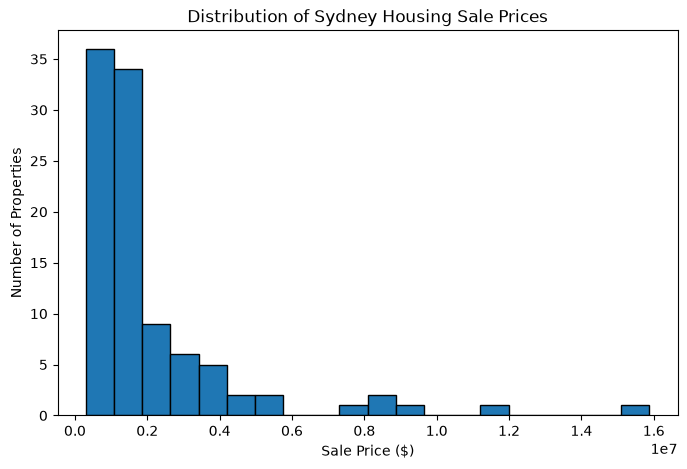

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(df["sale_price"], bins=20, edgecolor="black")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Sydney Housing Sale Prices")
plt.show()

In [57]:
df["sale_price"].skew()

np.float64(3.2576718288336295)

In [58]:
suburb_summary = df.groupby("suburb")["sale_price"].agg(["count", "mean", "median", "min", "max"])
suburb_summary

,count,mean,median,min,max
suburb,,,,,
liverpool,40,9.617250e+05,912500.0,300000,3100000
marrickville,30,1.656166e+06,1547500.0,780000,3500000
mosman,30,4.191500e+06,3297500.0,740000,15880000


<Figure size 800x500 with 0 Axes>

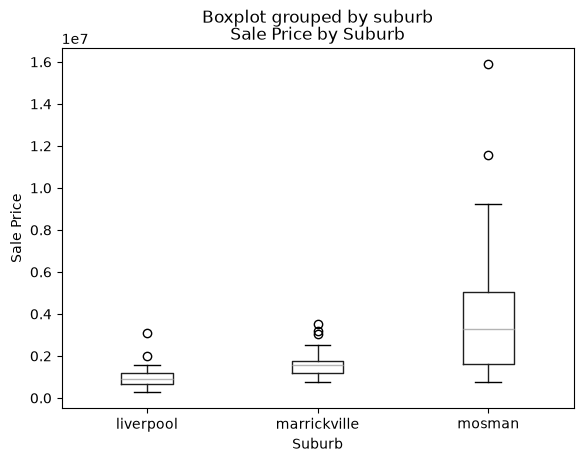

In [59]:
plt.figure(figsize=(8, 5))
df.boxplot(column="sale_price",by="suburb",grid=False)
plt.title("Sale Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price")
plt.show()

In [60]:
numeric_features = [
    "sale_price",
    "bedrooms",
    "bathrooms",
    "car_park",
    "land_size",
    "no_of_primary_schools",
    "no_of_secondary_schools",
    "distance_to_cbd"
]
correlation_matrix = df[numeric_features].corr()
correlation_matrix

,sale_price,bedrooms,bathrooms,car_park,land_size,no_of_primary_schools,no_of_secondary_schools,distance_to_cbd
sale_price,1.000000,0.281565,0.385157,0.275535,0.397403,NaN,-0.472154,-0.405649
bedrooms,0.281565,1.000000,0.901352,0.593667,0.729862,NaN,-0.128830,0.158923
bathrooms,0.385157,0.901352,1.000000,0.575788,0.573344,NaN,-0.164266,-0.012187
car_park,0.275535,0.593667,0.575788,1.000000,0.617130,NaN,-0.103819,0.185936
land_size,0.397403,0.729862,0.573344,0.617130,1.000000,NaN,-0.206902,0.273628
no_of_primary_schools,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_secondary_schools,-0.472154,-0.128830,-0.164266,-0.103819,-0.206902,NaN,1.000000,0.195496
distance_to_cbd,-0.405649,0.158923,-0.012187,0.185936,0.273628,NaN,0.195496,1.000000


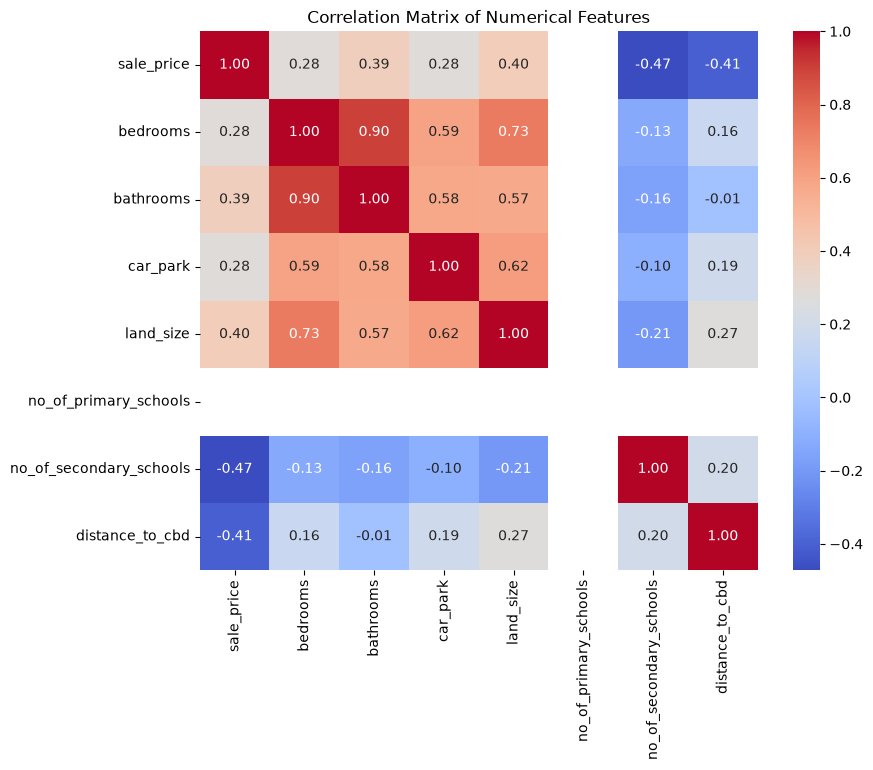

In [61]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [62]:
Q1 = df["sale_price"].quantile(0.25)
Q3 = df["sale_price"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 907500.0
Q3: 2335000.0
IQR: 1427500.0
Lower bound: -1233750.0
Upper bound: 4476250.0


In [63]:
outliers = df[
    (df["sale_price"] < lower_bound) |
    (df["sale_price"] > upper_bound)
]

outliers[
    [
        "address",
        "suburb",
        "sale_price",
        "property_type",
        "bedrooms",
        "bathrooms",
        "land_size"
    ]
]

,address,suburb,sale_price,property_type,bedrooms,bathrooms,land_size
0,"5 Botanic Road, Mosman, NSW 2088",mosman,8700000,House,4,3,437.0
2,"14 Erith Street, Mosman, NSW 2088",mosman,5300000,House,4,3,613.0
3,"10 Cyprian Street, Mosman, NSW 2088",mosman,8500000,House,4,3,556.0
5,"53 Clanalpine Street, Mosman, NSW 2088",mosman,7700000,House,5,5,511.0
7,"6 Lavoni Street, Mosman, NSW 2088",mosman,11550000,House,7,4,715.0
9,"15 Balmoral Avenue, Mosman, NSW 2088",mosman,15880000,House,5,4,788.0
15,"Unit 2/76 Spit Rd, Mosman, NSW 2088",mosman,9250000,Townhouse,3,1,160.0
16,"1/77A Muston Street, Mosman, NSW 2088",mosman,5300000,Townhouse,3,2,317.0


In [64]:
df_fe = df.drop(columns=['no_of_primary_schools','no_of_secondary_schools','address','postcode','sale_date'])

In [65]:
df_fe.head()

,suburb,sale_price,property_type,bedrooms,bathrooms,car_park,land_size,distance_to_cbd
0,mosman,8700000,House,4,3,2,437.0,10.4
1,mosman,3390000,House,4,3,2,379.0,7.4
2,mosman,5300000,House,4,3,1,613.0,8.3
3,mosman,8500000,House,4,3,2,556.0,9.7
4,mosman,3900000,House,5,3,2,624.0,9.5


In [66]:
x = df_fe.drop(columns=["sale_price"])
y = df_fe["sale_price"]

In [67]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [68]:
numeric_features = [
    "bedrooms",
    "bathrooms",
    "car_park",
    "land_size",
    "distance_to_cbd"
]

categorical_features = [
    "suburb",
    "property_type"
]

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train[numeric_features] = scaler.fit_transform(x_train[numeric_features])
x_test[numeric_features] = scaler.transform(x_test[numeric_features])

In [70]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
train_encoded = encoder.fit_transform(x_train[categorical_features])
test_encoded = encoder.transform(x_test[categorical_features])

In [71]:
encoded_columns = encoder.get_feature_names_out(categorical_features)
train_encoded_df = pd.DataFrame(train_encoded,columns=encoded_columns,index=x_train.index)
test_encoded_df = pd.DataFrame(test_encoded,columns=encoded_columns,index=x_test.index)
x_train = x_train.drop(columns=categorical_features)
x_test = x_test.drop(columns=categorical_features)
x_train = pd.concat([x_train, train_encoded_df],axis=1)
x_test = pd.concat([x_test, test_encoded_df],axis=1)
x_train.head()

,bedrooms,bathrooms,car_park,land_size,distance_to_cbd,suburb_marrickville,suburb_mosman,property_type_House,property_type_Townhouse
55,-0.434028,-0.523326,-1.411484,-0.877035,-0.711098,1.0,0.0,0.0,0.0
88,-0.434028,-0.523326,-0.446367,-0.724989,1.259768,0.0,0.0,0.0,1.0
26,-0.052465,0.101541,0.518750,-0.519521,-0.911526,0.0,1.0,0.0,0.0
42,-0.052465,-0.523326,-0.446367,-0.671567,-0.804631,1.0,0.0,0.0,1.0
69,0.329098,-0.523326,-0.446367,1.826924,1.139511,0.0,0.0,1.0,0.0


In [72]:
x_test.head()

,bedrooms,bathrooms,car_park,land_size,distance_to_cbd,suburb_marrickville,suburb_mosman,property_type_House,property_type_Townhouse
83,-0.434028,0.101541,0.518750,-0.371584,1.159554,0.0,0.0,0.0,1.0
53,-0.815591,-0.523326,-0.446367,-0.692114,-0.777907,1.0,0.0,0.0,0.0
70,-0.052465,-0.523326,2.448985,1.568034,1.259768,0.0,0.0,1.0,0.0
45,-0.434028,-0.523326,-0.446367,-0.379802,-0.804631,1.0,0.0,0.0,1.0
44,-0.815591,-0.523326,-0.446367,-0.519521,-0.851397,1.0,0.0,0.0,1.0


In part 2 I have decided to remove the features no_of_primary_schools, no_of_secondary_schools, address , postcode , sale_date as the exact address of the property does not contribute much to the house value instead it majorly depends on the suburb rather than the specific street. The feature postcode was a duplicate of the feature suburb as both of them essentially represented the same thing. In almost all the 3 suburbs there are atleast 4 primary schools or seconday schools within a radius of 2km so those features did not add much value to the final house price as people will be able to find schooling options irrespective of the suburb they choose. The sale date feature was removed as the total number of data points was only 100 and most of those data points represented only the recent sales but do not capture the historic data of even 2 years accurately. So the sale date feature was omitted for model training. 

In the process of data collection I also encountered some outliers in data which are mainly in the are of mosman due to the extreme prices of the suburb for bvery small piece of land mainy due to the closeness to the CBD region. Interqualite range was used to identify the outliers. 

<h1>Part 3: Model Development and Evaluation</h1>

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

linear_model = LinearRegression()
svr_model = SVR(kernel="rbf",C=100,epsilon=0.1)
rf_model = RandomForestRegressor(n_estimators=200,random_state=42)

kfold = KFold(n_splits=5,shuffle=True,random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

models = {
    "Linear Regression": linear_model,
    "SVR": svr_model,
    "Random Forest": rf_model
}

cv_results = []
for model_name, model in models.items():
    scores = cross_validate(model,x_train,y_train,cv=kfold,scoring=scoring)
    mae = -scores["test_MAE"].mean()
    mse = -scores["test_MSE"].mean()
    rmse = np.sqrt(mse)
    r2 = scores["test_R2"].mean()
    cv_results.append({
        "Model": model_name,
        "CV MAE": mae,
        "CV RMSE": rmse,
        "CV R2": r2
    })

In [74]:
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,CV MAE,CV RMSE,CV R2
0,Linear Regression,1.334306e+06,2.426029e+06,-0.363739
1,SVR,1.328858e+06,2.688150e+06,-0.138189
2,Random Forest,7.477176e+05,1.603138e+06,0.573069


In [75]:
linear_model.fit(x_train, y_train)
svr_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_results = []
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    train_mae = mean_absolute_error(y_train,y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))
    train_r2 = r2_score(y_train,y_train_pred)
    train_results.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train R2": train_r2
    })

In [77]:
train_results_df = pd.DataFrame(train_results)
train_results_df

,Model,Train MAE,Train RMSE,Train R2
0,Linear Regression,1.018997e+06,1.590462e+06,0.607334
1,SVR,1.303742e+06,2.681874e+06,-0.116486
2,Random Forest,2.713024e+05,5.915202e+05,0.945686


Linear Regression achieved a training R2 of 0.706 but an average cross-validation R2 of only 0.109. The decrease in performance indicates that the model did not generalise well across validation folds. SVR produced the weakest performance, with a cross-validation R2 of -0.138 and an MAE of approximately $1.33 million. Its training R2 was similarly poor at -0.116. Because training and validation performance were both weak and very similar, the model appears to be underfitting rather than overfitting. Random Forest produced the best cross-validation performance, achieving an MAE of approximately $738,000, RMSE of $1.57 million and R2 of 0.520. This indicates that it captured substantially more of the variation in housing prices than Linear Regression or SVR. However, its training R2 of 0.951 was considerably higher than its cross-validation R2, suggesting it might have overfitted. 

Before model development, Random Forest was expected to perform best because property prices are influenced by nonlinear relationships and interactions features. The output supported the expectation. Random Forest achieved the lowest cross-validation MAE and RMSE and the highest R2 of the three models. 

<h1>Part 4: Investigating Prediction Failures</h1>

In [78]:
y_pred = rf_model.predict(x_test)
results = x_test.copy()

results["Actual_Price"] = y_test.values
results["Predicted_Price"] = y_pred

results["Error"] = (
    results["Actual_Price"] -
    results["Predicted_Price"]
)

results["Absolute_Error"] = abs(results["Error"])
largest_errors = results.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

largest_errors

,bedrooms,bathrooms,car_park,land_size,distance_to_cbd,suburb_marrickville,suburb_mosman,property_type_House,property_type_Townhouse,Actual_Price,Predicted_Price,Error,Absolute_Error
4,0.710661,0.726407,0.518750,1.403660,-0.838036,0.0,1.0,1.0,0.0,3900000,7043075.00,-3143075.00,3143075.00
0,0.329098,0.726407,0.518750,0.635209,-0.777907,0.0,1.0,1.0,0.0,8700000,5578255.00,3121745.00,3121745.00
18,-0.052465,0.101541,0.518750,0.544804,-0.851397,0.0,1.0,0.0,1.0,4200000,5752500.00,-1552500.00,1552500.00
12,-0.434028,-0.523326,-0.446367,-0.585270,-0.824674,0.0,1.0,0.0,1.0,1735000,2780144.45,-1045144.45,1045144.45
31,-0.052465,-0.523326,-0.446367,0.968068,-0.744503,1.0,0.0,1.0,0.0,3170000,2232275.00,937725.00,937725.00


The top 5 largest errors of random forest eanged from $930000 to $3.14 million. Most of these errors occured in mosman. this is due to fact that the model is not able to generalize well on the suburb data as it has a lot of variation as it is the closest suburb to the CBD region. The main reason for the failure of generalization is high value areas are valued by different factors and not just by land size of house type which is missing in my dataset. Even the choice of interior can differ the price by a lot based on the quality of the materials used. The second reason could also be that very little data is used for training the model and the sparse data is not able to represent the complete variation in the market for the model to be generalised. 

<h1>Part 5: Human Judgement, Machine Learning, and Large Language Models</h2>

In [79]:
sample_10 = x_test.sample(
    n=10,
    random_state=42
)

sample_10

,bedrooms,bathrooms,car_park,land_size,distance_to_cbd,suburb_marrickville,suburb_mosman,property_type_House,property_type_Townhouse
83,-0.434028,0.101541,0.518750,-0.371584,1.159554,0.0,0.0,0.0,1.0
77,0.710661,0.726407,-0.446367,0.195508,1.219682,0.0,0.0,1.0,0.0
4,0.710661,0.726407,0.518750,1.403660,-0.838036,0.0,1.0,1.0,0.0
53,-0.815591,-0.523326,-0.446367,-0.692114,-0.777907,1.0,0.0,0.0,0.0
10,-0.052465,0.101541,0.518750,-0.371584,-0.985015,0.0,1.0,0.0,1.0
39,-0.052465,-0.523326,-0.446367,-0.461990,-0.804631,1.0,0.0,1.0,0.0
30,0.329098,0.726407,0.518750,-0.174334,-0.804631,1.0,0.0,1.0,0.0
45,-0.434028,-0.523326,-0.446367,-0.379802,-0.804631,1.0,0.0,0.0,1.0
12,-0.434028,-0.523326,-0.446367,-0.585270,-0.824674,0.0,1.0,0.0,1.0
76,1.473787,0.101541,1.483868,1.452972,1.219682,0.0,0.0,1.0,0.0


In [80]:
sample_10_original = df.loc[sample_10.index].copy()

sample_10_original

,address,suburb,postcode,sale_price,sale_date,property_type,bedrooms,bathrooms,car_park,land_size,no_of_primary_schools,no_of_secondary_schools,distance_to_cbd
83,"4/66 Passefield Street, Liverpool, NSW 2170",liverpool,2170,795000,2026-04-09,Townhouse,2,2,2,192.0,5,5,39.4
77,"17Phillip Street, Liverpool, NSW 2170",liverpool,2170,1420000,2026-05-02,House,5,3,1,330.0,5,5,40.3
4,"31 Ryrie Street, Mosman, NSW 2088",mosman,2088,3900000,2026-03-07,House,5,3,2,624.0,5,3,9.5
53,"102/1-13 Garners Avenue, Marrickville, NSW 2204",marrickville,2204,1085000,2026-08-28,Apartment,1,1,1,114.0,5,5,10.4
10,"10/116 Belmont Road, Mosman, NSW 2088",mosman,2088,2380000,2026-06-10,Townhouse,3,2,2,192.0,5,5,7.3
39,"52 Illawarra Road, Marrickville, NSW 2204",marrickville,2204,1735000,2026-07-25,House,3,1,1,170.0,5,5,10.0
30,"73b Illawarra Road, Marrickville, NSW 2204",marrickville,2204,3055000,2026-09-16,House,4,3,2,240.0,5,5,10.0
45,"3/130 Wardell Road, Marrickville, NSW 2204",marrickville,2204,1610000,2025-11-15,Townhouse,2,1,1,190.0,5,5,10.0
12,"3/1B Badham Avenue, Mosman, NSW 2088",mosman,2088,1735000,2025-03-07,Townhouse,2,1,1,140.0,5,4,9.7
76,"8 & 8A Phillip Street, Liverpool, NSW 2170",liverpool,2170,1400000,2026-05-04,House,7,2,3,636.0,5,5,40.3


In [81]:
sample_10_original = sample_10_original[
    [
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_park",
        "land_size",
        "distance_to_cbd",
        "sale_price"
    ]
]

sample_10_original

,suburb,property_type,bedrooms,bathrooms,car_park,land_size,distance_to_cbd,sale_price
83,liverpool,Townhouse,2,2,2,192.0,39.4,795000
77,liverpool,House,5,3,1,330.0,40.3,1420000
4,mosman,House,5,3,2,624.0,9.5,3900000
53,marrickville,Apartment,1,1,1,114.0,10.4,1085000
10,mosman,Townhouse,3,2,2,192.0,7.3,2380000
39,marrickville,House,3,1,1,170.0,10.0,1735000
30,marrickville,House,4,3,2,240.0,10.0,3055000
45,marrickville,Townhouse,2,1,1,190.0,10.0,1610000
12,mosman,Townhouse,2,1,1,140.0,9.7,1735000
76,liverpool,House,7,2,3,636.0,40.3,1400000


In [84]:
ml_predictions = rf_model.predict(
    x_test.loc[sample_10.index]
)
ml_predictions

array([ 852355.  , 1949780.  , 7043075.  , 1327674.05, 3287775.  ,
       1842554.7 , 2497014.95, 1657859.35, 2780144.45, 1940695.  ])

In [85]:
sample_10_original["ML_Prediction"] = ml_predictions

In [86]:
sample_10_original["LLM_Prediction"] = [780000,1450000,9500000,1050000,3700000,2000000,2600000,1500000,2200000,1500000]

In [87]:
sample_10_original["Human_Prediction"] = [900000,1500000,10000000,13000000,3200000,1800000,2000000,1200000,1800000,1200000]

In [88]:
sample_10_original["ML_Error"] = abs(sample_10_original["sale_price"] - sample_10_original["ML_Prediction"])
sample_10_original["LLM_Error"] = abs(sample_10_original["sale_price"] - sample_10_original["LLM_Prediction"])
sample_10_original["Human_Error"] = abs(sample_10_original["sale_price"] - sample_10_original["Human_Prediction"])

In [89]:
comparison = sample_10_original[
    [
        "suburb",
        "property_type",
        "sale_price",
        "ML_Prediction",
        "LLM_Prediction",
        "Human_Prediction",
        "ML_Error",
        "LLM_Error",
        "Human_Error"
    ]
]

comparison

,suburb,property_type,sale_price,ML_Prediction,LLM_Prediction,Human_Prediction,ML_Error,LLM_Error,Human_Error
83,liverpool,Townhouse,795000,852355.00,780000,900000,57355.00,15000,105000
77,liverpool,House,1420000,1949780.00,1450000,1500000,529780.00,30000,80000
4,mosman,House,3900000,7043075.00,9500000,10000000,3143075.00,5600000,6100000
53,marrickville,Apartment,1085000,1327674.05,1050000,13000000,242674.05,35000,11915000
10,mosman,Townhouse,2380000,3287775.00,3700000,3200000,907775.00,1320000,820000
39,marrickville,House,1735000,1842554.70,2000000,1800000,107554.70,265000,65000
30,marrickville,House,3055000,2497014.95,2600000,2000000,557985.05,455000,1055000
45,marrickville,Townhouse,1610000,1657859.35,1500000,1200000,47859.35,110000,410000
12,mosman,Townhouse,1735000,2780144.45,2200000,1800000,1045144.45,465000,65000
76,liverpool,House,1400000,1940695.00,1500000,1200000,540695.00,100000,200000


In [90]:
ml_mae = sample_10_original["ML_Error"].mean()
llm_mae = sample_10_original["LLM_Error"].mean()
human_mae = sample_10_original["Human_Error"].mean()

print(f"ML MAE:    ${ml_mae:,.2f}")
print(f"LLM MAE:   ${llm_mae:,.2f}")
print(f"Human MAE: ${human_mae:,.2f}")

ML MAE:    $717,989.76
LLM MAE:   $839,500.00
Human MAE: $2,081,500.00


The machine learning models performed best for the case where extreme values are not involved. So for most properties the machine learning mdoels was able to generalize well and give reasonable predections. But when the predectd the value of premium properties the machine learning models failed to give decent predections as many features that define the price for premium properties was not captured in the training data. On this case the Large Language Model performed better but it was not able to guess the right prices for the general properties which the machine learnign mdoels were able to do it more better. Even though LLMs could understand the locality and the demand it did not have access to large data points of sales to understand the exact market value. The human predection compared to both of these was best at identifying the mistakes made by both these models as in if the price was too much or too less compared what was being offfered. 

<h1>Part 6: Final Deployment and Reflection</h1>

In [91]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']